In [2]:
import pandas as pd
import json

# Load the dataset
file_path = 'Supplemental_Python_Remote.csv'
job_descriptions_df = pd.read_csv(file_path)
job_descriptions_df = job_descriptions_df[:500]

Elbow Plot, Scores

/Users/aadyapipersenia/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/aadyapipersenia/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/aadyapipersenia/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/aadyapipersenia/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of

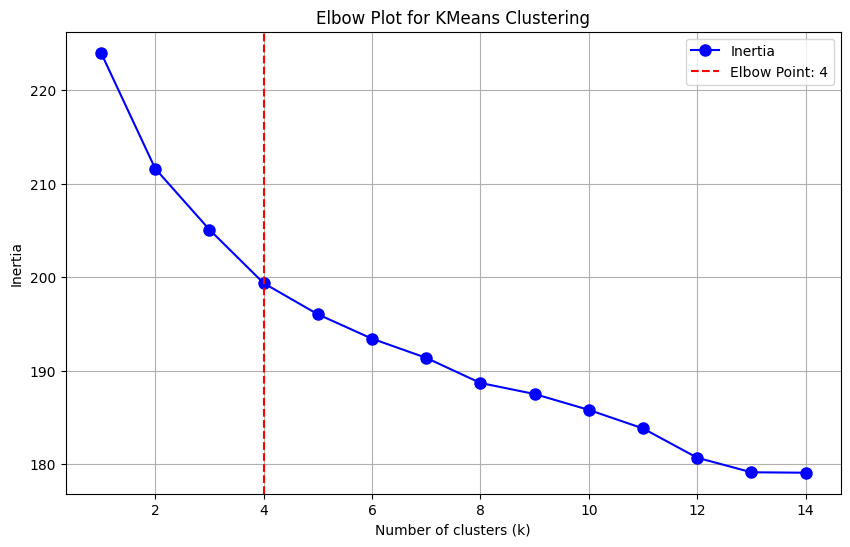

The elbow point is at k = 4


In [3]:
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from kneed import KneeLocator

# Load embeddings from JSON file
with open('JD_embeddings.json', 'r') as file:
    embeddings_data = json.load(file)

# Extract embeddings and store them in a numpy array
embeddings = [item['embedding'] for item in embeddings_data]
embeddings_array = np.array(embeddings)

# Determine the range of clusters to evaluate
cluster_range = range(1, 15)  # You can adjust the range as needed
inertia_values = []

# Calculate inertia for each number of clusters
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(embeddings_array)
    inertia_values.append(kmeans.inertia_)

# Use the KneeLocator to find the elbow point
kneedle = KneeLocator(cluster_range, inertia_values, curve="convex", direction="decreasing")
elbow_point = kneedle.elbow

# Plot the elbow plot
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertia_values, 'bo-', markersize=8, label='Inertia')
plt.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow Point: {elbow_point}')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot for KMeans Clustering')
plt.legend()
plt.grid(True)
plt.show()

print(f"The elbow point is at k = {elbow_point}")


1536


/Users/aadyapipersenia/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cluster Labels [6 6 6 5 5 9 3 6 7 1 3 5 1 1 1 3 1 1 1 1 4 9 1 1 1 7 1 9 1 1 1 0 4 1 6 3 1
 3 6 1 7 3 1 7 4 7 1 0 4 4 1 8 7 4 4 4 9 4 1 5 4 0 4 4 8 2 3 1 9 1 4 3 9 1
 1 1 1 8 7 0 6 9 5 7 7 4 7 4 0 7 4 1 6 1 7 0 5 3 6 7 5 1 4 6 1 1 6 3 1 7 4
 6 9 1 7 0 8 7 6 2 7 4 7 6 7 5 5 5 3 0 5 9 1 8 6 6 5 4 9 7 1 0 2 6 4 8 4 6
 9 7 9 3 0 6 4 7 7 6 7 6 5 4 6 0 4 4 4 7 9 0 8 7 3 5 4 1 4 6 5 3 1 1 4 7 2
 4 6 7 1 8 6 6 7 6 7 0 4 7 4 8 0 9 5 4 6 1 3 4 7 1 2 4 3 4 4 7 4 5 4 5 8 5
 1 3 4 4 5 4 8 4 0 8 6 6 3 3 0 5 5 4 5 2 1 9 0 6 4 2 4 4 4 7 8 2 7 1 1 8 4
 9 3 7 7 6 4 6 7 3 2 4 4 4 7 9 4 9 4 5 6 4 6 4 3 3 6 2 5 4 4 1 0 9 6 7 3 5
 0 1 7 5 6 6 6 1 1 6 3 1 1 1 4 1 4 7 1 1 1 1 1 1 1 4 6 1 1 1 4 0 1 3 6 3 7
 7 3 4 1 4 1 1 4 0 8 7 8 4 0 8 7 8 4 4 2 5 9 4 1 4 0 3 4 0 3 4 4 4 6 1 3 4
 7 1 3 1 7 6 0 7 3 0 4 7 5 8 2 0 4 9 9 1 9 0 9 7 4 1 9 7 0 6 8 1 6 5 1 5 1
 7 8 5 6 0 4 6 6 1 1 5 4 6 0 7 9 7 7 7 8 7 6 9 8 6 2 1 4 5 7 8 4 9 2 7 9 2
 5 0 4 6 6 5 5 6 6 7 1 7 7 3 0 7 6 1 4 9 7 6 1 4 9 7 9 6 0 3 7 9 7 5 3 7 3
 0 7 4 4 6

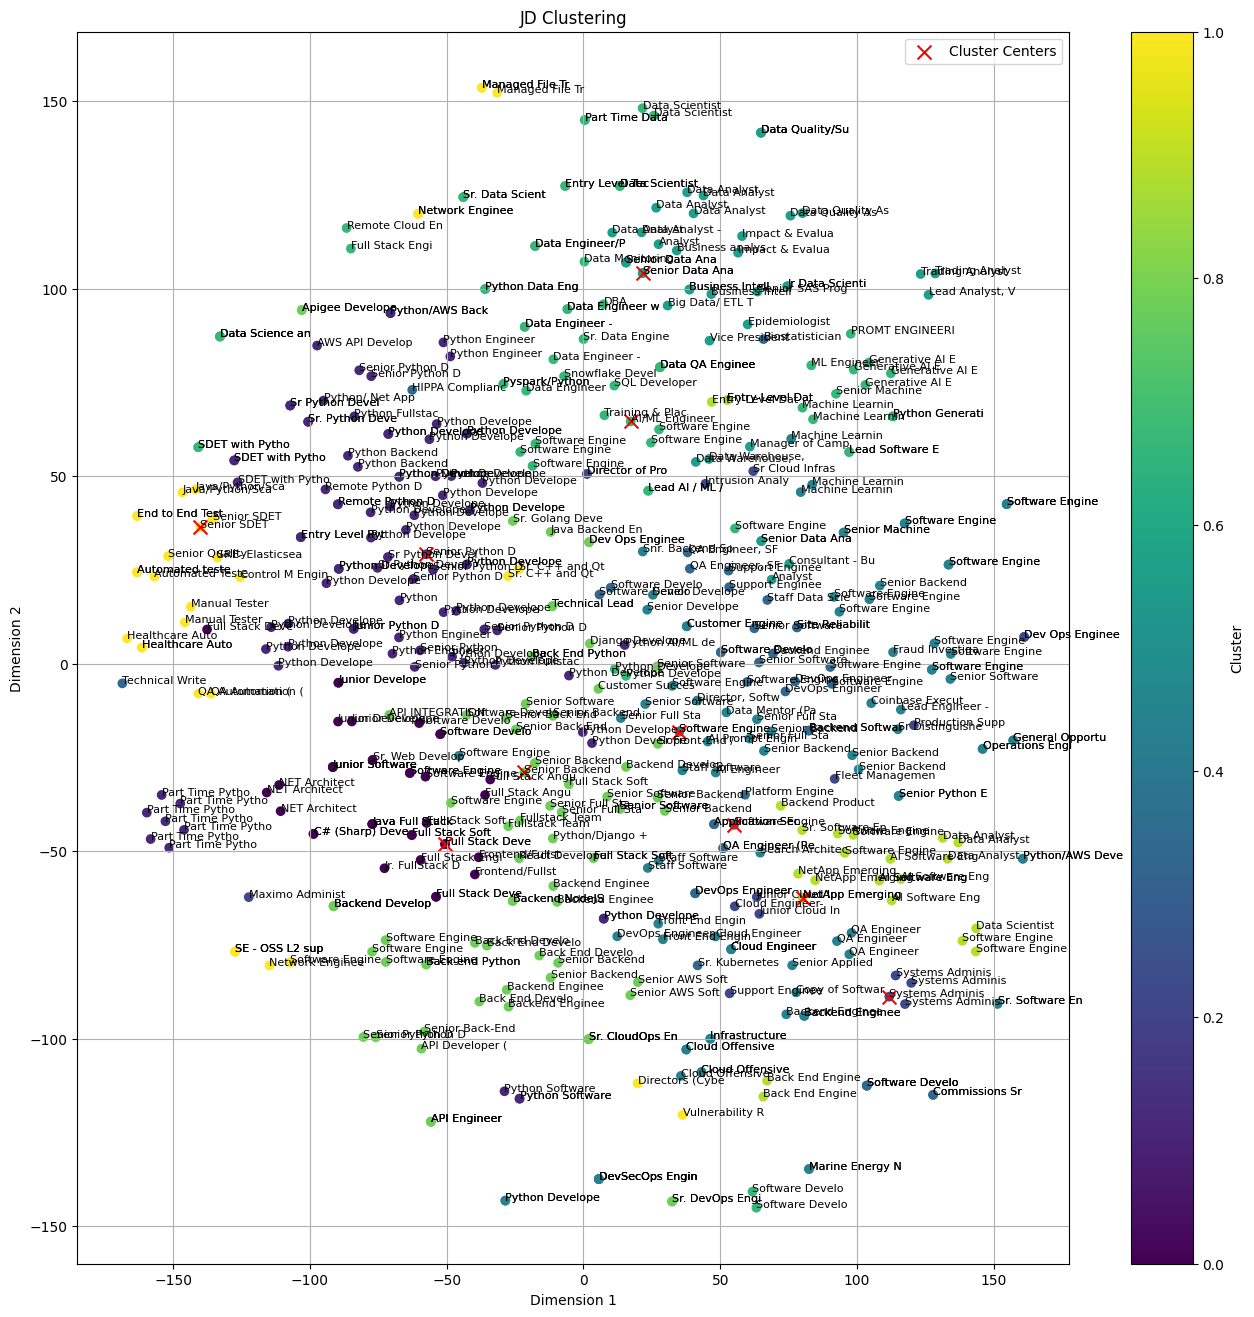

In [4]:
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score, davies_bouldin_score
# Load embeddings from JSON file
with open('JD_embeddings.json', 'r') as file:
    embeddings_data = json.load(file)

# Extract embeddings and store them in a numpy array
embeddings = []
for item in embeddings_data:
    embeddings.append(item['embedding'])

titles = [item['title'] for item in embeddings_data]

embeddings_array = np.array(embeddings)
print(len(embeddings[0]))


# Perform clustering
kmeans = KMeans(n_clusters=10)  
kmeans.fit(embeddings_array)
cluster_labels = kmeans.labels_
cluster_centers = kmeans.cluster_centers_

print("Cluster Labels", cluster_labels)
print("Cluster Centers", cluster_centers)

# Compute metrics
silhouette_avg = silhouette_score(embeddings_array, cluster_labels)
inertia = kmeans.inertia_
davies_bouldin = davies_bouldin_score(embeddings_array, cluster_labels)

print(f"Silhouette Score: {silhouette_avg}")
print(f"Inertia (Sum of Squared Distances to Closest Centroid): {inertia}")
print(f"Davies-Bouldin Index: {davies_bouldin}")

# Function to transform new points (cluster centers) using the learned t-SNE transformation
def transform_centers_to_2d(tsne_model, original_data, centers, reduced_data):
    # Compute pairwise distances between original data and centers
    pairwise_dists = cdist(original_data, centers, metric='cosine')
    # Find nearest neighbors in the original space
    nearest_neighbors = np.argmin(pairwise_dists, axis=0)
    # Use their 2D t-SNE coordinates as cluster center representations
    reduced_centers = reduced_data[nearest_neighbors]
    return reduced_centers


# Reduce dimensionality of embeddings for visualization
tsne = TSNE(random_state = 0, n_iter = 1000, metric = 'cosine', perplexity=30)
# tsne2 = TSNE(random_state = 0, n_iter = 1000, metric = 'cosine', perplexity=4)
reduced_embeddings = tsne.fit_transform(embeddings_array)

# Transform cluster centers to 2D
reduced_cluster_centers = transform_centers_to_2d(tsne, embeddings_array, cluster_centers, reduced_embeddings)

print(reduced_embeddings.shape)
print(len(reduced_embeddings[0]))
# Plot the reduced embeddings
plt.figure(figsize=(16, 16))

# Plot each point and color it according to the cluster label
# for i in range(len(reduced_embeddings)):
#     plt.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1], c=[cluster_labels[i]], cmap='viridis')

plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c = cluster_labels, cmap= 'viridis')
for i in range(len(reduced_embeddings)):
    # Annotate each point with its skill
    plt.text(reduced_embeddings[i, 0], reduced_embeddings[i, 1], titles[i][:15], fontsize=8)


# Plot the cluster centers obtained from KMeans
plt.scatter(reduced_cluster_centers[:, 0], reduced_cluster_centers[:, 1], marker='x', s=100, c='red', label='Cluster Centers')
plt.title('JD Clustering')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()


In [5]:
job_descriptions_df['Cluster'] = cluster_labels

In [22]:
skills_df = pd.read_excel('Hyphen_Removed_Skills_Data.xlsx')
# Get the list of skills from the third column
skills = skills_df.iloc[:, 2].dropna().tolist()
skills = pd.unique(skills).tolist()
skills
len(skills) 

/var/folders/b7/5s7w4rhj08n_d300vg9kq81m0000gn/T/ipykernel_30363/1438386625.py:4: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  skills = pd.unique(skills).tolist()


812

In [23]:
import pandas as pd
import numpy as np
import json

# Load embeddings and job descriptions
with open('JD_embeddings.json', 'r') as file:
    embeddings_data = json.load(file)

# Extract job titles and descriptions
job_titles = [item['title'] for item in embeddings_data]
job_descriptions = [item['description'] for item in embeddings_data]  # Assuming 'description' contains the job descriptions


# Create an empty DataFrame for the JD-Skill matrix
jd_skill_matrix = pd.DataFrame(0, index=job_titles, columns=skills)

# Function to count the occurrences of skills in a text
def count_skills(text, skills_list):
    skill_counts = {skill: 0 for skill in skills_list}
    for skill in skills_list:
        skill_counts[skill] = text.lower().count(skill.lower())
    return skill_counts

# Populate the JD-Skill matrix
for i, job_description in enumerate(job_descriptions):
    skill_counts = count_skills(job_description, skills)
    for skill, count in skill_counts.items():
        jd_skill_matrix.loc[job_titles[i], skill] = count

print("JD-Skill Matrix created successfully!")


JD-Skill Matrix created successfully!


In [24]:
# Assuming 'cluster_labels' is available from previous clustering
job_titles_df = pd.DataFrame({'Job_Title': job_titles, 'Cluster': cluster_labels})

# Merge the JD-Skill matrix with cluster labels
jd_skill_matrix['Cluster'] = job_titles_df['Cluster'].values

# Sum the rows cluster-wise
cluster_skill_matrix = jd_skill_matrix.groupby('Cluster').sum()

print("Cluster-Skill Matrix created successfully!")

Cluster-Skill Matrix created successfully!


In [25]:
cluster_skill_matrix 

,Python,R,SQL,Java,Scala,C,C++,Javascript,Matlab,"Julia, Ruby",...,API design and development,Interpersonal skills,Time management,Continuous learning,Selfmotivation,Problemsolving,Critical thinking,Stakeholder management,Customer service,Writing skills
Cluster,,,,,,,,,,,,,,,,,,,,,
0,53,4258,36,63,17,2499,0,30,0,0,...,0,0,4,3,0,8,0,0,0,0
1,680,13679,113,57,20,8343,0,46,0,0,...,0,4,1,4,0,52,0,0,0,0
2,21,4967,12,5,9,3187,0,0,0,0,...,0,2,0,4,1,10,4,0,9,0
3,67,9620,38,23,14,6236,0,14,0,0,...,0,2,1,2,1,5,0,0,2,0
4,167,23990,62,57,65,14490,0,46,2,0,...,0,4,3,10,0,23,3,0,8,0
5,51,8603,45,6,10,5610,0,6,0,0,...,0,0,0,6,0,11,6,2,0,0
6,146,6917,48,28,21,4081,0,12,0,0,...,0,3,0,4,0,20,2,0,1,0
7,136,12089,62,57,64,7129,0,43,0,0,...,0,4,3,7,0,23,2,0,4,2
8,41,6251,20,15,4,3571,0,8,0,0,...,0,0,0,1,0,9,0,0,0,0


In [26]:
# Initialize a DataFrame to store the top skills in each cluster
top_skills_per_cluster = pd.DataFrame(columns=['Skill', 'Cluster', 'Frequency'])

# Keep track of already assigned skills
assigned_skills = set()

# Transpose the DataFrame for easier processing
transposed_df = cluster_skill_matrix.T

# Iterate over each cluster to find the top 5 skills
for cluster in transposed_df.columns:
    # Sort skills by frequency in descending order
    sorted_skills = transposed_df[cluster].sort_values(ascending=False)
    
    # Select top skills that are not already assigned to other clusters
    top_skills = sorted_skills[~sorted_skills.index.isin(assigned_skills)].head(20)  # Adjust top_n as needed
    
    # Update assigned_skills with the selected top skills
    assigned_skills.update(top_skills.index)
    
    # Prepare DataFrame for top skills in this cluster
    top_skills_df = pd.DataFrame({
        'Skill': top_skills.index,
        'Cluster': cluster,
        'Frequency': top_skills.values
    })
    
    # Append to the final DataFrame
    top_skills_per_cluster = pd.concat([top_skills_per_cluster, top_skills_df], ignore_index=True)

# Drop any duplicated rows in case they exist due to previous issues
top_skills_per_cluster = top_skills_per_cluster.drop_duplicates()

# Display the top skills per cluster
print("Top Skills per Cluster:")
print(top_skills_per_cluster)

# Optionally, save the top skills per cluster to a CSV file
top_skills_per_cluster.to_csv('clust_skills_JD_embedd.csv', index=False)

print("Top skills per cluster saved to 'top_skills_per_cluster.csv'")

Top Skills per Cluster:
                                             Skill Cluster Frequency
0                                                R       0      4258
1                                                C       0      2499
2                                             Java       0        63
3                                           Python       0        53
4                                             Stan       0        41
..                                             ...     ...       ...
195                                   Graph theory       9         0
196                                 Linear algebra       9         0
197                 Teaching and knowledge sharing       9         0
198                        Evolutionary strategies       9         0
199  Client interaction and stakeholder management       9         0

[200 rows x 3 columns]
Top skills per cluster saved to 'top_skills_per_cluster.csv'


In [27]:
import openai
from openai import OpenAI
# OPENAI_API_KEY = 'REDACTED'
client = OpenAI(api_key='REDACTED',)

In [28]:
def generate_curriculum(file):
    data = pd.read_csv(file)
    skills = data.to_string(index=False)
    response = client.chat.completions.create(
    model="gpt-4-0125-preview",
    messages=[
            {"role": "system", "content": "You are a helpful assistant specialized in analysing the skills which have been clustered based on the embeddings of the job descriptions."},
            {"role": "user", "content": f"""I have a CSV file containing skills with their frequency across different clusters from job descriptions. I need to cluster these skills based on their relatedness and then design a curriculum with around 10 courses, allocating the clustered skills to each course. CSV_content:{skills}
            Give the output as curriculum designed with about 10 courses, the similar skills grouped together. Remember, the curriculum design is for a Masters in Management in Artificial Intelligence Program (MMAI), intersection of MBA and AI, so feel free to drop in other relevant skills in the courses which might have been missed in the {skills}
            """}], 
    max_tokens = 4096,
    temperature = 0,
    top_p = 1
  )
    response_content = response.choices[0].message.content
   # Parse response content as JSON
    print(response_content)
    # Save the collected skills and their embeddings to a JSON file
    with open('curriculum_JD_embedd_skills.json', 'w') as json_file:
      json.dump(response_content, json_file, indent=4)

In [29]:
generate_curriculum('clust_skills_JD_embedd.csv')

Designing a curriculum for a Masters in Management in Artificial Intelligence (MMAI) program involves integrating core AI technologies with management and business strategies. The curriculum outlined below clusters related skills into 10 courses, aiming to provide a comprehensive education at the intersection of AI and management.

### Course 1: Introduction to Programming and Data Science
- **Skills Covered**: Python, R, Java, SQL, Python Programming, Statistics, Data Analysis, Data Visualization, Math, Mathematics, Statistical Analysis
- **Objective**: To equip students with foundational programming skills and an understanding of data science principles.

### Course 2: Advanced Machine Learning and AI
- **Skills Covered**: Machine Learning, Deep Learning, TensorFlow, Keras, PyTorch, Scikitlearn, NLTK, spaCy, Machine Learning Algorithms, Feature engineering, Reinforcement learning, Computer Vision
- **Objective**: To dive deep into machine learning algorithms, neural networks, and AI'

In [30]:
# Initialize co-occurrence matrix
num_skills = len(skills)
co_occurrence_matrix = np.zeros((num_skills, num_skills))

# Create a dictionary mapping skills to indices
skill_to_index = {skill: idx for idx, skill in enumerate(skills)}

# Populate the co-occurrence matrix
for _, row in jd_skill_matrix.iterrows():
    present_skills = row[row > 0].index.tolist()
    for i in range(len(present_skills)):
        skill1 = present_skills[i]
        if skill1 == 'Cluster':  # Skip the 'Cluster' column
            continue
        for j in range(i + 1, len(present_skills)):
            skill2 = present_skills[j]
            if skill2 == 'Cluster':  # Skip the 'Cluster' column
                continue
            idx1 = skill_to_index[skill1]
            idx2 = skill_to_index[skill2]
            co_occurrence_matrix[idx1, idx2] = 1
            co_occurrence_matrix[idx2, idx1] = 1

# Convert to DataFrame for better readability (optional)
co_occurrence_df = pd.DataFrame(co_occurrence_matrix, index=skills, columns=skills)


In [33]:
file_path = 'co_occurrence_JD_skills_cluster.csv'
co_occurrence_df.to_csv(file_path, index=True)

In [34]:
co_occurrence_df

,Python,R,SQL,Java,Scala,C,C++,Javascript,Matlab,"Julia, Ruby",...,API design and development,Interpersonal skills,Time management,Continuous learning,Selfmotivation,Problemsolving,Critical thinking,Stakeholder management,Customer service,Writing skills
Python,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
R,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
SQL,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Java,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
Scala,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Problemsolving,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
Critical thinking,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
Stakeholder management,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Customer service,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


In [18]:
num_entries_one = np.count_nonzero(co_occurrence_matrix == 1)

In [19]:
num_entries_one

18982